# GPU Performance Profiling: ResNet-18 Forward Pass

This notebook uses torch.profiler to instrument ResNet-18's forward
pass on an NVIDIA T4 GPU, identifying which operations dominate
execution time and where bottlenecks exist. Profiling is the primary
diagnostic tool for GPU workload performance analysis (why a model is slower than expected and where
optimization effort should be directed).

In [1]:
!pip install torchvision -q

In [2]:
import os
import torch
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np

In [3]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Running on: GPU (profiling both CPU and CUDA activity)")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
Running on: GPU (profiling both CPU and CUDA activity)


In [4]:
# Load ResNet-18 pretrained on ImageNet
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Move model to GPU
# .cuda() moves all model parameters and buffers to GPU VRAM
model = model.cuda()
model.eval()

print("Model loaded and moved to GPU")
print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")

Model loaded and moved to GPU
Number of parameters: 11,689,512


In [5]:
# Create dummy input on GPU
dummy_input = torch.randn(1, 3, 224, 224).cuda()

# Warmup runs
# GPU needs to initialize before measurements are meaningful
# Also allows any JIT compilation to happen before profiling
print("Running warmup...")
for _ in range(10):
    with torch.no_grad():
        _ = model(dummy_input)

torch.cuda.synchronize()
print("Warmup complete")

Running warmup...
Warmup complete


In [6]:
# torch.profiler.profile is a context manager
# Everything inside the 'with' block gets instrumented
with torch.profiler.profile(
    activities=[
        # Profile CPU operations (Python overhead, data movement)
        torch.profiler.ProfilerActivity.CPU,
        # Profile CUDA operations (actual GPU computation)
        torch.profiler.ProfilerActivity.CUDA,
    ],
    # record_shapes=True captures the input/output tensor shapes
    # for each operation (useful for understanding memory usage)
    record_shapes=True,
    # profile_memory=True tracks GPU memory allocation per operation
    profile_memory=True,
    # with_stack=True records Python call stack for each operation
    # helps trace back to which line of code triggered each op
    with_stack=True
) as prof:
    with torch.no_grad():
        output = model(dummy_input)
    # Synchronize to ensure all GPU operations complete
    # before the profiler stops recording
    torch.cuda.synchronize()

print("Profiling complete")
print(f"Output shape: {output.shape}")

Profiling complete
Output shape: torch.Size([1, 1000])


/usr/local/lib/python3.12/dist-packages/torch/profiler/profiler.py:217: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


In [7]:
# Sort by CUDA time - this shows which operations
# actually dominated GPU execution time
print("=== TOP 20 OPERATIONS BY CUDA TIME ===")
print(prof.key_averages().table(
    sort_by="cuda_time_total",
    row_limit=20
))

=== TOP 20 OPERATIONS BY CUDA TIME ===
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                           aten::conv2d         1.27%     121.767us        65.03%       6.213ms     310.643us       0.000us         0.00%       3.001ms     150.032us           0 B  

In [8]:
# This view shows the gap between CPU dispatch time and GPU execution time
# Large gap means the GPU is doing most of the real work (good)
# Small gap means CPU overhead is dominating (bad - GPU is underutilized)
print("=== CPU vs CUDA TIME COMPARISON ===")
print(prof.key_averages().table(
    sort_by="cpu_time_total",
    row_limit=10
))

=== CPU vs CUDA TIME COMPARISON ===
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                           aten::conv2d         1.27%     121.767us        65.03%       6.213ms     310.643us       0.000us         0.00%       3.001ms     150.032us           0 B     

In [9]:
averages = prof.key_averages()

cuda_ops = [
    event for event in averages
    if event.self_device_time_total > 0
    # Filter out profiling overhead
    and "Activity Buffer" not in event.key
]
cuda_ops.sort(key=lambda x: x.self_device_time_total, reverse=True)

top_ops = cuda_ops[:10]

winograd_count = 0
op_names = []
for op in top_ops:
    name = op.key
    name = name.replace("aten::", "")
    if len(name) > 30:
        if "winograd" in name.lower():
            winograd_count += 1
            name = f"cudnn_winograd_{winograd_count}"
        elif "convolve_sgemm" in name.lower():
            name = "implicit_convolve_sgemm"
        elif "bn_fw" in name.lower() or "batch_norm" in name.lower():
            name = "cudnn_batch_norm_kernel"
        elif "nhwc" in name.lower():
            name = "cudnn_conv_nhwc"
        elif "elementwise" in name.lower():
            name = "vectorized_elementwise"
        elif "nchw" in name.lower():
            name = "nchwToNhwc_kernel"
        else:
            name = "cudnn_conv_large"
    op_names.append(name)

cuda_times = [op.self_device_time_total / 1000 for op in top_ops]
cpu_times = [op.self_cpu_time_total / 1000 for op in top_ops]

print(f"Top operation by CUDA time: {op_names[0]}")
print(f"Total CUDA time: {sum(cuda_times):.2f} ms")
print(f"Top 10 ops account for: {sum(cuda_times)/sum([e.self_device_time_total/1000 for e in cuda_ops])*100:.1f}% of total CUDA time")
print()
print("Operation names for chart:")
for name, t in zip(op_names, cuda_times):
    print(f"  {name}: {t:.2f}ms")

Top operation by CUDA time: cudnn_convolution
Total CUDA time: 6.07 ms
Top 10 ops account for: 94.8% of total CUDA time

Operation names for chart:
  cudnn_convolution: 2.89ms
  cudnn_winograd_1: 1.65ms
  cudnn_winograd_2: 0.51ms
  implicit_convolve_sgemm: 0.28ms
  cudnn_conv_nhwc: 0.20ms
  cudnn_batch_norm: 0.14ms
  cudnn_batch_norm_kernel: 0.14ms
  cudnn_conv_large: 0.11ms
  clamp_min_: 0.07ms
  vectorized_elementwise: 0.07ms


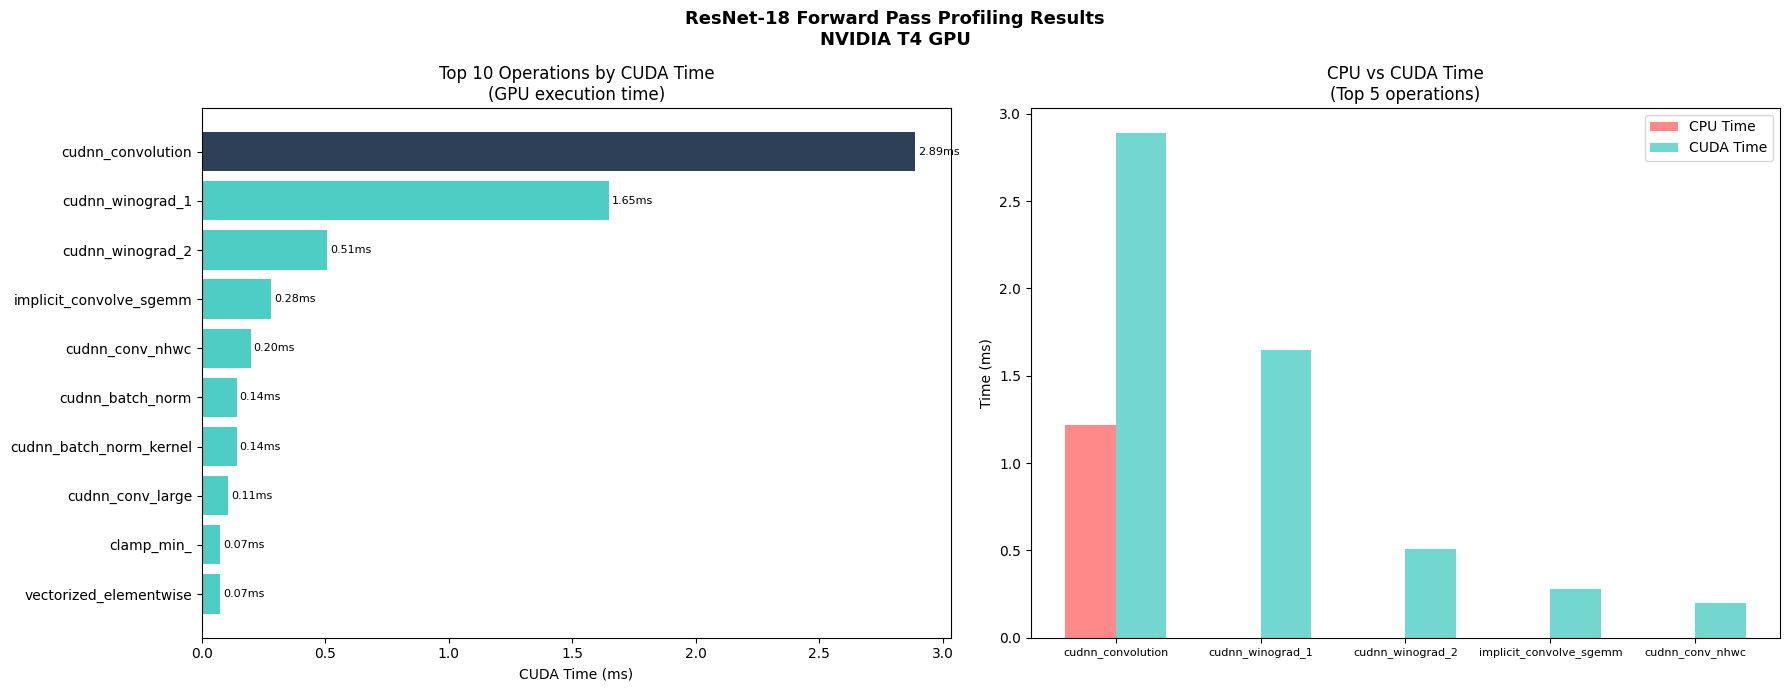

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

colors_cuda = ['#2E4057' if i == 0 else '#4ecdc4' for i in range(len(op_names))]
colors_cpu = ['#cc3333' if i == 0 else '#ff9999' for i in range(len(op_names))]

# Chart 1: CUDA time breakdown
bars1 = axes[0].barh(op_names[::-1], cuda_times[::-1], color=colors_cuda[::-1])
axes[0].set_xlabel('CUDA Time (ms)')
axes[0].set_title('Top 10 Operations by CUDA Time\n(GPU execution time)')
for bar, t in zip(bars1, cuda_times[::-1]):
    axes[0].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'{t:.2f}ms', va='center', fontsize=8)

# Chart 2: CPU vs CUDA time for top 5
x = np.arange(5)
width = 0.35
axes[1].bar(x - width/2, cpu_times[:5], width, label='CPU Time', color='#ff6b6b', alpha=0.8)
axes[1].bar(x + width/2, cuda_times[:5], width, label='CUDA Time', color='#4ecdc4', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(op_names[:5], fontsize=8)
axes[1].set_ylabel('Time (ms)')
axes[1].set_title('CPU vs CUDA Time\n(Top 5 operations)')
axes[1].legend()

plt.suptitle('ResNet-18 Forward Pass Profiling Results\nNVIDIA T4 GPU',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('profiling_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Export profiler trace in Chrome trace format
# This can be loaded into chrome://tracing for interactive visualization
# showing a timeline of every operation with microsecond precision
prof.export_chrome_trace("resnet18_trace.json")
print("Chrome trace saved to resnet18_trace.json")
print("To view: open Chrome, go to chrome://tracing, click Load, select the file")
print("This shows a Gantt chart of every operation on both CPU and GPU timelines")

Chrome trace saved to resnet18_trace.json
To view: open Chrome, go to chrome://tracing, click Load, select the file
This shows a Gantt chart of every operation on both CPU and GPU timelines


In [12]:
total_cuda = sum(e.self_device_time_total for e in cuda_ops) / 1000
total_cpu = sum(e.self_cpu_time_total for e in averages) / 1000

print("=== PROFILING SUMMARY ===")
print(f"Total CUDA execution time: {total_cuda:.2f} ms")
print(f"Total CPU time: {total_cpu:.2f} ms")
print(f"GPU utilization ratio: {total_cuda/total_cpu:.2f}x")
print()
print(f"Dominant operation: {op_names[0]} — {cuda_times[0]:.2f} ms ({cuda_times[0]/total_cuda*100:.1f}% of total CUDA time)")
print()
print("Top 10 operations breakdown:")
for name, t in zip(op_names, cuda_times):
    print(f"  {name}: {t:.2f} ms ({t/total_cuda*100:.1f}%)")

=== PROFILING SUMMARY ===
Total CUDA execution time: 6.40 ms
Total CPU time: 9.55 ms
GPU utilization ratio: 0.67x

Dominant operation: cudnn_convolution — 2.89 ms (45.1% of total CUDA time)

Top 10 operations breakdown:
  cudnn_convolution: 2.89 ms (45.1%)
  cudnn_winograd_1: 1.65 ms (25.8%)
  cudnn_winograd_2: 0.51 ms (7.9%)
  implicit_convolve_sgemm: 0.28 ms (4.4%)
  cudnn_conv_nhwc: 0.20 ms (3.1%)
  cudnn_batch_norm: 0.14 ms (2.2%)
  cudnn_batch_norm_kernel: 0.14 ms (2.2%)
  cudnn_conv_large: 0.11 ms (1.7%)
  clamp_min_: 0.07 ms (1.2%)
  vectorized_elementwise: 0.07 ms (1.2%)
